# Tarea 04 — Visualización de Datos con Matplotlib

**Instrucciones:** Completa cada celda de código con tu respuesta.  
Usarás la interfaz orientada a objetos de Matplotlib (`fig, ax = plt.subplots()`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataset de trabajo
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

In [13]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## Parte 1 — Figura y ejes

**P1.** Crea una figura con `plt.subplots()` de tamaño 8×5.  
Haz un gráfico de línea con los primeros 20 valores de `sepal_length`.  
Agrega título `"Longitud del sépalo"` y etiquetas en ambos ejes.

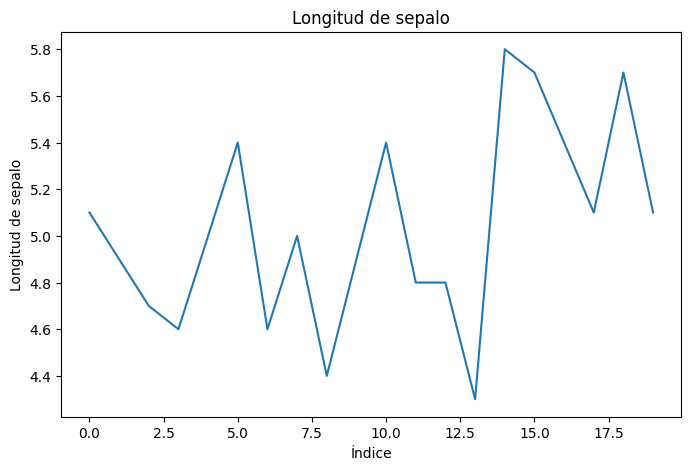

In [12]:
# Tu respuesta aquí

fig, ax = plt.subplots(figsize = (8 , 5))
ax.plot(df["sepal_length"][:20])
ax.set_title("Longitud de sepalo")
ax.set_xlabel("Índice")
ax.set_ylabel("Longitud de sepalo")
plt.show()

---
## Parte 2 — Gráfico de barras

**P2.** Calcula el promedio de `petal_length` por especie (`species`) y guárdalo en una variable.  
Luego crea un **gráfico de barras vertical** con esos promedios.  
Agrega título y etiquetas en ambos ejes.

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64


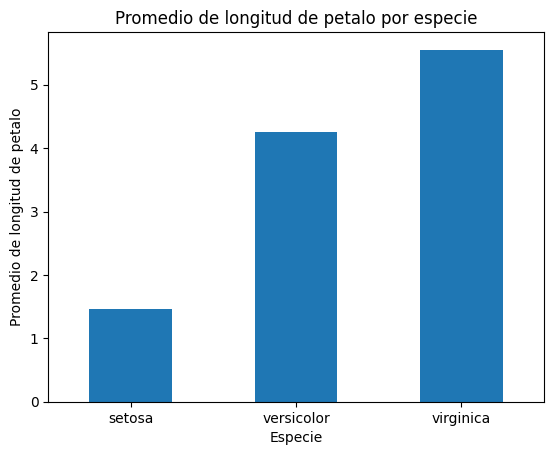

In [21]:
# Tu respuesta aquí
# Promedio
promedio = df.groupby("species")["petal_length"].mean()
print(promedio)

# Histograma de los promedios
promedio.plot(kind = "bar")
plt.title("Promedio de longitud de petalo por especie")
plt.xlabel("Especie")
plt.xticks(rotation = 0)
plt.ylabel("Promedio de longitud de petalo")
plt.show()


---
## Parte 3 — Dispersión (scatter plot)

**P3.** Crea un **gráfico de dispersión** (scatter) con `sepal_length` en el eje X y `sepal_width` en el eje Y.  
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).  
Agrega leyenda, título y etiquetas.

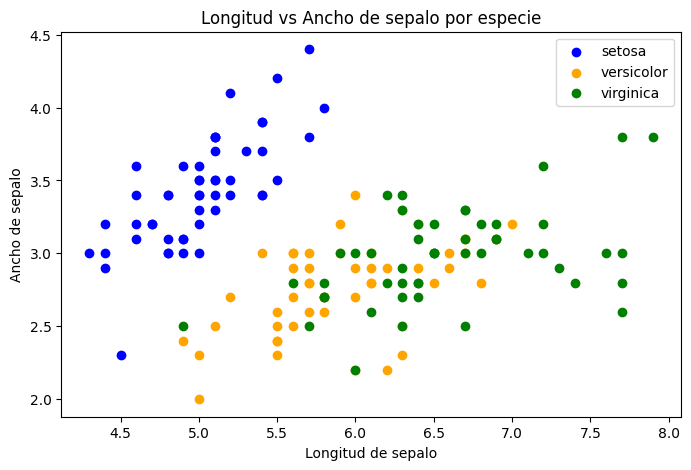

In [30]:
especies = df["species"].unique()
colores = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

for especie, color in zip(especies, colores):
    grupo = df[df["species"] == especie]
    ax.scatter(grupo["sepal_length"], grupo["sepal_width"], color = color, label = especie)
ax.set_title("Longitud vs Ancho de sepalo por especie")
ax.set_xlabel("Longitud de sepalo")
ax.set_ylabel("Ancho de sepalo")
ax.legend()
plt.show()


---
## Parte 4 — Histograma

**P4.** Crea un **histograma** de la columna `petal_width` con 15 bins.  
Agrega una línea vertical punteada en el valor de la media con `ax.axvline()`.  
Agrega título y etiquetas.

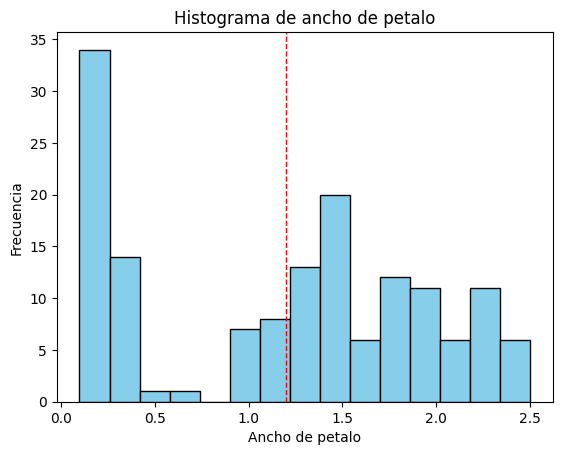

In [34]:
# Tu respuesta aquí
plt.hist(df["petal_width"], bins = 15, color = "skyblue", edgecolor = "black")
plt.title("Histograma de ancho de petalo")
plt.xlabel("Ancho de petalo")
plt.axvline(df["petal_width"].mean(), color = "red", linestyle = "dashed", linewidth = 1, label = "Media")
plt.ylabel("Frecuencia")
plt.show()


---
## Parte 5 — Guardar figura

**P5.** Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en `output/promedios_iris.png`.  
Usa `dpi=100` y `bbox_inches="tight"`.

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64


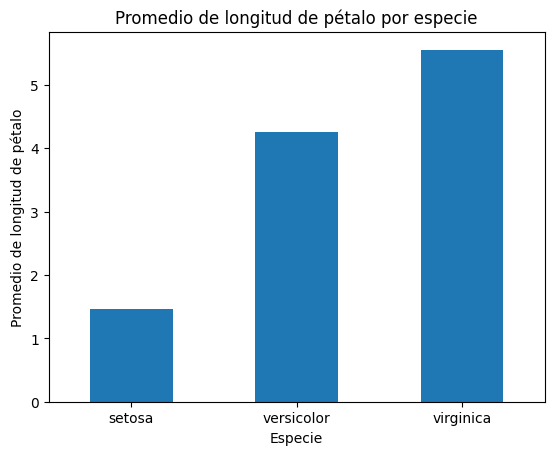

In [36]:
import os
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)

# Promedio
promedio = df.groupby("species")["petal_length"].mean()
print(promedio)

# Gráfico
promedio.plot(kind="bar")

plt.title("Promedio de longitud de pétalo por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio de longitud de pétalo")
plt.xticks(rotation=0)

plt.savefig("output/promedios_iris.png", dpi=100, bbox_inches="tight")

plt.show()
